# HCP Brain Network — Topology, Roles & Efficiency–Resilience Tradeoffs

This notebook analyses the HCP structural connectivity network through two complementary lenses:

1. **Weighted vs Unweighted comparison** — how topology and centrality differ when edge weights are ignored
2. **Node role classification** — hub, broker, and bridge identification in brain network context
3. **Efficiency–Resilience tradeoff** — applying the framework from:
   > Bianchi et al. (2022). *Efficiency and resilience of trade networks.* Environmental Research Letters. https://doi.org/10.1088/1748-9326/ac1a9b

**Libraries:** `networkx`, `numpy`, `scipy`, `pandas`, `matplotlib`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
from scipy import stats

from enigmatoolbox.datasets import load_sc

%matplotlib inline
print('Imports successful.')

Imports successful.


In [3]:
# ── Load HCP SC data ──────────────────────────────────────────────────────────
sc_ctx, sc_ctx_labels, sc_sctx, sc_sctx_labels = load_sc()
n = sc_ctx.shape[0]  # 68 cortical regions

# ── Build weighted and unweighted graphs ──────────────────────────────────────
G_w  = nx.from_numpy_array(sc_ctx)                      # weighted
A_bin = (sc_ctx > 0).astype(float)                      # binarize
G_uw = nx.from_numpy_array(A_bin)                       # unweighted

print(f'Nodes          : {n}')
print(f'Weighted edges : {G_w.number_of_edges()}')
print(f'Density        : {nx.density(G_w):.3f}')
print(f'Connected      : {nx.is_connected(G_w)}')

Nodes          : 68
Weighted edges : 697
Density        : 0.306
Connected      : True


---
## Section 1: Weighted vs Unweighted Network Comparison

**Why compare?**  
- **Unweighted** — captures binary presence of anatomical connections; treats all tracts equally  
- **Weighted** — encodes tract density (streamline count); strong tracts contribute more to topology  

If centrality rankings are stable across both versions, the topology is robust.  
Where they diverge, edge weights carry meaningful biological signal.

In [4]:
# ── Centrality on both weighted and unweighted graphs ─────────────────────────

# Degree
deg_w  = np.array([d for _, d in G_w.degree(weight='weight')])
deg_uw = np.array([d for _, d in G_uw.degree()])

# Betweenness (use inverse weight as distance for weighted)
G_w_dist = G_w.copy()
for u, v, d in G_w_dist.edges(data=True):
    d['distance'] = 1.0 / (d['weight'] + 1e-9)

btw_w  = np.array(list(nx.betweenness_centrality(G_w_dist,  weight='distance', normalized=True).values()))
btw_uw = np.array(list(nx.betweenness_centrality(G_uw,                          normalized=True).values()))

# Eigenvector
eig_w  = np.array(list(nx.eigenvector_centrality_numpy(G_w,  weight='weight').values()))
eig_uw = np.array(list(nx.eigenvector_centrality_numpy(G_uw, weight=None).values()))

# Correlate weighted vs unweighted rankings
r_deg, _ = stats.spearmanr(deg_w,  deg_uw)
r_btw, _ = stats.spearmanr(btw_w,  btw_uw)
r_eig, _ = stats.spearmanr(eig_w,  eig_uw)

print('Spearman rank correlation (weighted vs unweighted):')
print(f'  Degree centrality    : r = {r_deg:.3f}')
print(f'  Betweenness centrality: r = {r_btw:.3f}')
print(f'  Eigenvector centrality: r = {r_eig:.3f}')

Spearman rank correlation (weighted vs unweighted):
  Degree centrality    : r = 0.928
  Betweenness centrality: r = 0.806
  Eigenvector centrality: r = 0.862


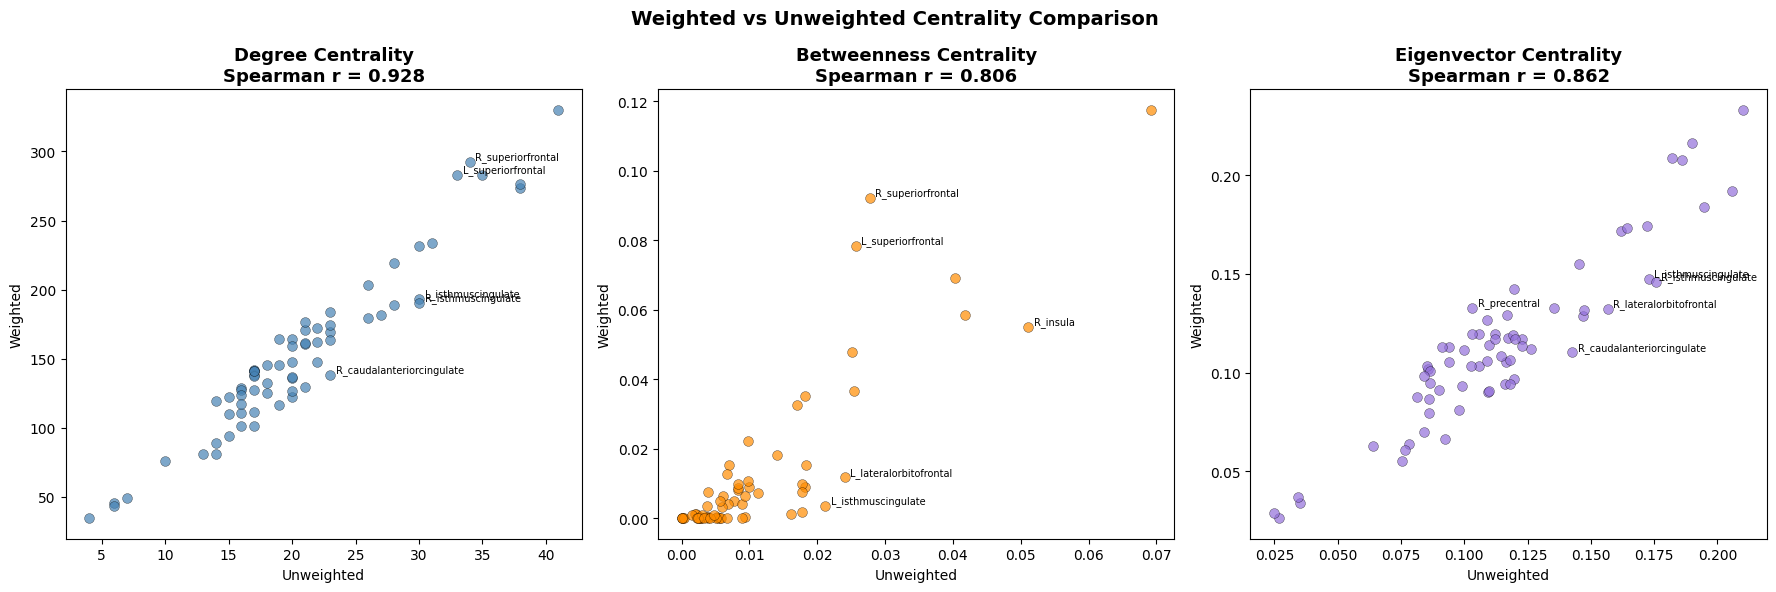

In [5]:
# ── Scatter: weighted vs unweighted centrality ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pairs = [
    (deg_uw,  deg_w,  'Degree',       r_deg, 'steelblue'),
    (btw_uw,  btw_w,  'Betweenness',  r_btw, 'darkorange'),
    (eig_uw,  eig_w,  'Eigenvector',  r_eig, 'mediumpurple'),
]

for ax, (x, y, name, r, color) in zip(axes, pairs):
    ax.scatter(x, y, c=color, s=50, alpha=0.7, edgecolors='k', linewidths=0.3)
    # Label top diverging nodes
    diff = np.abs(stats.zscore(x) - stats.zscore(y))
    for i in np.argsort(diff)[::-1][:5]:
        ax.annotate(sc_ctx_labels[i], (x[i], y[i]), fontsize=7,
                    xytext=(4, 2), textcoords='offset points')
    ax.set_title(f'{name} Centrality\nSpearman r = {r:.3f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Unweighted')
    ax.set_ylabel('Weighted')

plt.suptitle('Weighted vs Unweighted Centrality Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hcp_weighted_vs_unweighted.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2: Node Role Classification

Nodes are classified into three functional roles based on their network topology:

| Role | Brain context | Detection method |
|---|---|---|
| **Hub** | High-connectivity region; integrates information across the whole brain (e.g. precuneus, posterior cingulate) | Top quartile of weighted strength AND eigenvector centrality |
| **Broker** | Lies on many shortest paths; controls information flow between otherwise weakly connected areas | Top quartile of betweenness centrality |
| **Bridge** | Sole or rare connector between two clusters; removal would disconnect communities | Low degree + high betweenness (gatekeepers) |

**Why it matters:**  
Hubs support global efficiency; brokers gate communication between modules; bridges are structural bottlenecks whose failure (lesion, disease) can disconnect the network.

In [6]:
# ── Detect communities (Louvain / greedy modularity) ──────────────────────────
# Use unweighted graph for community detection
communities = list(nx.community.greedy_modularity_communities(G_uw))
community_map = {}
for comm_id, comm in enumerate(communities):
    for node in comm:
        community_map[node] = comm_id

community_arr = np.array([community_map[i] for i in range(n)])
print(f'Number of communities detected: {len(communities)}')
for i, c in enumerate(communities):
    print(f'  Community {i}: {len(c)} nodes — {[sc_ctx_labels[n] for n in sorted(c)][:5]}...')

Number of communities detected: 3
  Community 0: 27 nodes — [np.str_('R_bankssts'), np.str_('R_caudalmiddlefrontal'), np.str_('R_cuneus'), np.str_('R_entorhinal'), np.str_('R_fusiform')]...
  Community 1: 26 nodes — [np.str_('L_bankssts'), np.str_('L_caudalmiddlefrontal'), np.str_('L_cuneus'), np.str_('L_entorhinal'), np.str_('L_fusiform')]...
  Community 2: 15 nodes — [np.str_('L_caudalanteriorcingulate'), np.str_('L_isthmuscingulate'), np.str_('L_medialorbitofrontal'), np.str_('L_paracentral'), np.str_('L_posteriorcingulate')]...


In [7]:
# ── Classify node roles ───────────────────────────────────────────────────────
strength  = deg_w                                # weighted strength
between   = btw_w                                # betweenness (weighted)
eigen     = eig_w                                # eigenvector (weighted)
degree_bin = deg_uw                              # binary degree

# Z-score each measure
z_str  = stats.zscore(strength)
z_btw  = stats.zscore(between)
z_eig  = stats.zscore(eigen)
z_deg  = stats.zscore(degree_bin)

# ── Hub: high strength AND high eigenvector ───────────────────────────────────
is_hub    = (z_str > 1.0) & (z_eig > 1.0)

# ── Broker: high betweenness ──────────────────────────────────────────────────
is_broker = (z_btw > 1.0) & ~is_hub

# ── Bridge: low degree but high betweenness (gatekeeper) ─────────────────────
is_bridge = (z_btw > 0.5) & (z_deg < 0.0) & ~is_hub & ~is_broker

# ── Role summary dataframe ────────────────────────────────────────────────────
role_arr = np.full(n, 'Peripheral', dtype=object)
role_arr[is_bridge] = 'Bridge'
role_arr[is_broker] = 'Broker'
role_arr[is_hub]    = 'Hub'

role_df = pd.DataFrame({
    'Region'     : sc_ctx_labels,
    'Community'  : community_arr,
    'Strength'   : strength.round(3),
    'Betweenness': between.round(4),
    'Eigenvector': eigen.round(4),
    'Role'       : role_arr,
})

print('Node role counts:')
print(role_df['Role'].value_counts().to_string())
print()
for role in ['Hub', 'Broker', 'Bridge']:
    regions = role_df[role_df['Role'] == role]['Region'].tolist()
    print(f'{role:10s}: {regions}')

Node role counts:
Role
Peripheral    59
Hub            9

Hub       : ['L_precuneus', 'L_rostralmiddlefrontal', 'L_superiorfrontal', 'L_superiorparietal', 'L_insula', 'R_precuneus', 'R_superiorfrontal', 'R_superiorparietal', 'R_insula']
Broker    : []
Bridge    : []


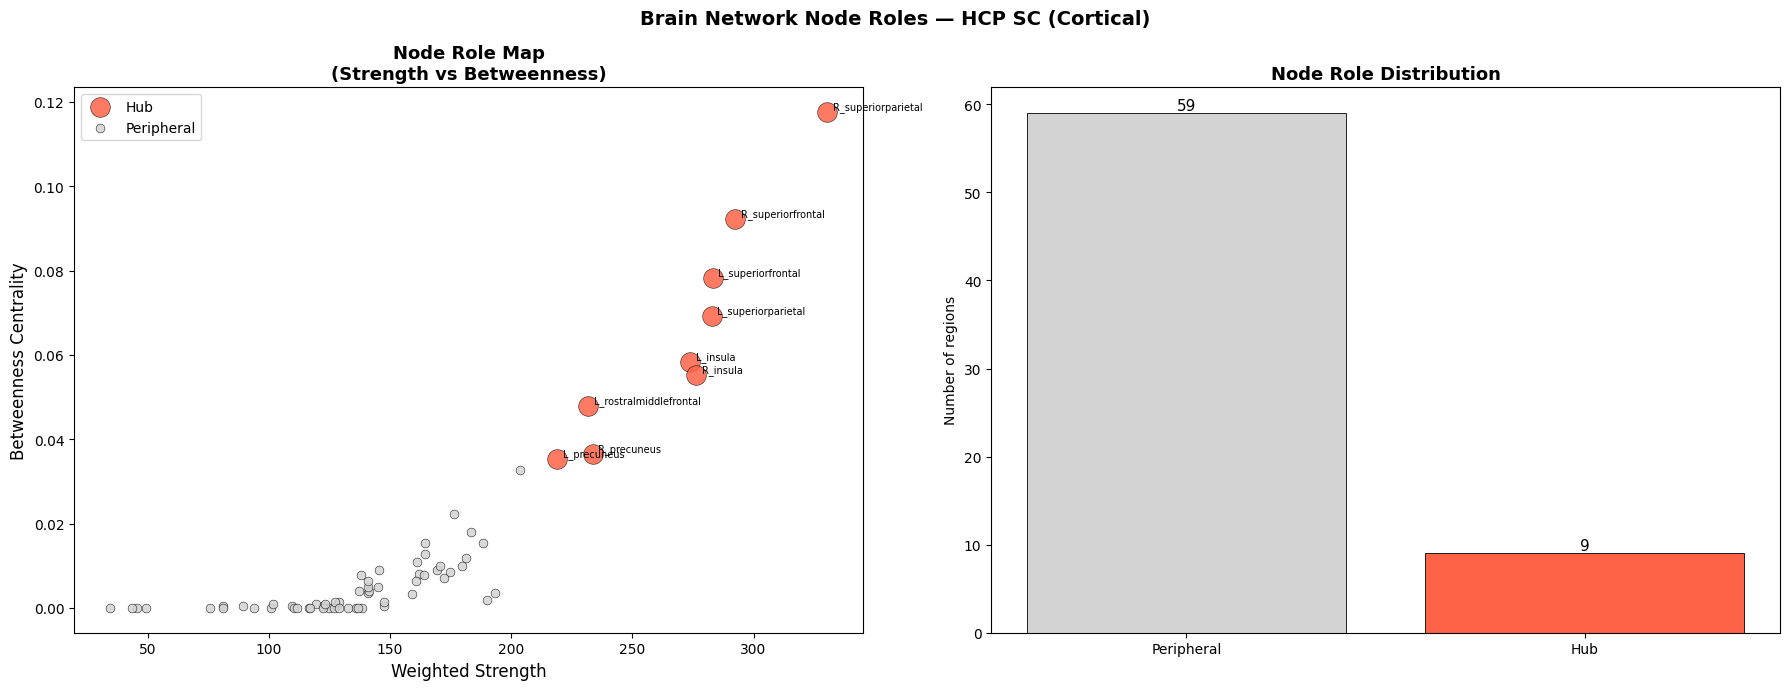

In [8]:
# ── Visualize node roles ───────────────────────────────────────────────────────
role_colors = {'Hub': 'tomato', 'Broker': 'darkorange', 'Bridge': 'steelblue', 'Peripheral': 'lightgray'}
role_sizes  = {'Hub': 200,      'Broker': 120,          'Bridge': 100,          'Peripheral': 40}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: Strength vs Betweenness scatter with role colours ──────────────────
for role, grp in role_df.groupby('Role'):
    axes[0].scatter(grp['Strength'], grp['Betweenness'],
                    c=role_colors[role], s=role_sizes[role],
                    label=role, edgecolors='k', linewidths=0.4, alpha=0.85, zorder=3)
for _, row in role_df[role_df['Role'] != 'Peripheral'].iterrows():
    axes[0].annotate(row['Region'], (row['Strength'], row['Betweenness']),
                     fontsize=7, xytext=(4, 2), textcoords='offset points')

axes[0].set_xlabel('Weighted Strength', fontsize=12)
axes[0].set_ylabel('Betweenness Centrality', fontsize=12)
axes[0].set_title('Node Role Map\n(Strength vs Betweenness)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# ── Right: role count bar chart ───────────────────────────────────────────────
counts = role_df['Role'].value_counts()
bars = axes[1].bar(counts.index, counts.values,
                   color=[role_colors[r] for r in counts.index],
                   edgecolor='k', linewidth=0.6)
axes[1].bar_label(bars, fontsize=11)
axes[1].set_title('Node Role Distribution', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of regions')

plt.suptitle('Brain Network Node Roles — HCP SC (Cortical)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hcp_node_roles.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3: Efficiency–Resilience Tradeoff

Following [Bianchi et al. 2022](https://doi.org/10.1088/1748-9326/ac1a9b), we compute:

### Topological (Unweighted) Metrics
| Metric | Formula | Interpretation |
|---|---|---|
| Average path length | d̂ = Σdᵢⱼ / N(N-1) | Shorter = more efficient |
| Spectral radius | λ₁ = max eigenvalue | Higher = faster spread / less resilient |
| Epidemic threshold | τ = 1/λ₁ | Higher = more resilient to spread |
| Node-removal resilience | Λ = (λ₁ - λ₁') / λ₁ | Drop after removing top hub |

### Tradeoff Parameters
| Parameter | Formula | Interpretation |
|---|---|---|
| α (node attack) | Λ / (d̂ + Λ) | →1 efficient, →0 resilient |
| β (epidemic spread) | (1/τ) / ((1/τ) + d̂) | →1 efficient, →0 resilient |

### Weighted Metrics
| Metric | Formula | Interpretation |
|---|---|---|
| Weighted resilience | R = (ΣW - max W) / ΣW | Fraction remaining after top hub removed |
| Weighted efficiency | E = Σ(dᵢⱼ / wᵢⱼ) / N(N-1) | Lower = more efficient (stronger paths) |
| ρ (cooperation) | (1 - Ẽ) / R̃ | >1 efficient-dominated, <1 resilience-dominated |
| ξ (design quality) | (1 - Ẽ) + R̃ | →2 well-designed, →0 poorly designed |

In [9]:
# ── Topological efficiency & resilience ───────────────────────────────────────

# Average shortest path length (unweighted)
d_hat = nx.average_shortest_path_length(G_uw)

# Spectral radius λ₁ (largest eigenvalue of binary adjacency)
eigvals_uw = np.linalg.eigvalsh(A_bin)
lambda1_uw = eigvals_uw.max()
tau = 1.0 / lambda1_uw   # epidemic threshold

# Node-removal resilience: remove highest-degree hub, recompute λ₁
hub_node = int(np.argmax(degree_bin))
A_removed = np.delete(np.delete(A_bin, hub_node, axis=0), hub_node, axis=1)
lambda1_prime = np.linalg.eigvalsh(A_removed).max()
Lambda = (lambda1_uw - lambda1_prime) / lambda1_uw * 100   # % drop

# Tradeoff parameters
alpha = Lambda / (d_hat + Lambda)          # node-attack tradeoff
beta  = (1/tau) / ((1/tau) + d_hat)       # epidemic tradeoff

print('── Topological Metrics ──────────────────────────')
print(f'  Average path length d̂     : {d_hat:.4f}')
print(f'  Spectral radius λ₁         : {lambda1_uw:.4f}')
print(f'  Epidemic threshold τ        : {tau:.4f}')
print(f'  Hub removed                : {sc_ctx_labels[hub_node]}')
print(f'  λ₁ after removal           : {lambda1_prime:.4f}')
print(f'  Node-removal resilience Λ  : {Lambda:.2f}%')
print()
print('── Tradeoff Parameters ──────────────────────────')
print(f'  α (node attack)  : {alpha:.4f}  ({"efficient" if alpha > 0.5 else "resilient"}-dominant)')
print(f'  β (epidemic)     : {beta:.4f}  ({"efficient" if beta > 0.5 else "resilient"}-dominant)')

── Topological Metrics ──────────────────────────
  Average path length d̂     : 1.7291
  Spectral radius λ₁         : 23.0335
  Epidemic threshold τ        : 0.0434
  Hub removed                : R_superiorparietal
  λ₁ after removal           : 22.0171
  Node-removal resilience Λ  : 4.41%

── Tradeoff Parameters ──────────────────────────
  α (node attack)  : 0.7185  (efficient-dominant)
  β (epidemic)     : 0.9302  (efficient-dominant)


In [10]:
# ── Weighted efficiency & resilience ──────────────────────────────────────────

# Weighted resilience: fraction of total strength remaining after removing top hub
W_out = sc_ctx.sum(axis=1)   # strength per node
R_gamma = (W_out.sum() - W_out.max()) / W_out.sum()

# Weighted efficiency: mean of (hop-distance / edge-weight) for connected pairs
# Use shortest path in hop count, divided by the direct edge weight
path_lengths = dict(nx.all_pairs_shortest_path_length(G_uw))
E_vals = []
for i in range(n):
    for j in range(n):
        if i != j and sc_ctx[i, j] > 0:
            d_ij = path_lengths[i].get(j, np.nan)
            w_ij = sc_ctx[i, j]
            if not np.isnan(d_ij):
                E_vals.append(d_ij / w_ij)
E_gamma = np.mean(E_vals)

# Normalise to [0,1] for cooperation parameters
# E_gamma: lower = better efficiency → invert normalise so Ẽ→1 means fully efficient
E_max   = np.max(E_vals)
E_min   = np.min(E_vals)
E_norm  = 1 - (E_gamma - E_min) / (E_max - E_min + 1e-9)   # Ẽ: 1=efficient
R_norm  = R_gamma                                             # R̃ already in [0,1]

rho = (1 - E_norm) / (R_norm + 1e-9)    # cooperation parameter ρ
xi  = (1 - E_norm) + R_norm              # cooperation parameter ξ

print('── Weighted Metrics ─────────────────────────────')
print(f'  Weighted resilience R(Γ)   : {R_gamma:.4f}')
print(f'  Weighted efficiency E(Γ)   : {E_gamma:.6f}')
print(f'  Ẽ (normalised efficiency)  : {E_norm:.4f}')
print()
print('── Cooperation Parameters ───────────────────────')
print(f'  ρ = {rho:.4f}  → {"efficiency" if rho > 1 else "resilience"}-dominated')
print(f'  ξ = {xi:.4f}  → {"well" if xi > 1 else "poorly"}-designed ({xi:.2f}/2.0)')

── Weighted Metrics ─────────────────────────────
  Weighted resilience R(Γ)   : 0.9680
  Weighted efficiency E(Γ)   : 0.153358
  Ẽ (normalised efficiency)  : 0.8978

── Cooperation Parameters ───────────────────────
  ρ = 0.1056  → resilience-dominated
  ξ = 1.0702  → well-designed (1.07/2.0)


Robustness index (weighted) : 0.4585
Robustness index (binary)   : 0.4606


/tmp/ipykernel_26973/2868568229.py:36: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  R_idx_w  = np.trapz(lcc_w,  steps_w)
/tmp/ipykernel_26973/2868568229.py:37: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  R_idx_uw = np.trapz(lcc_uw, steps_uw)


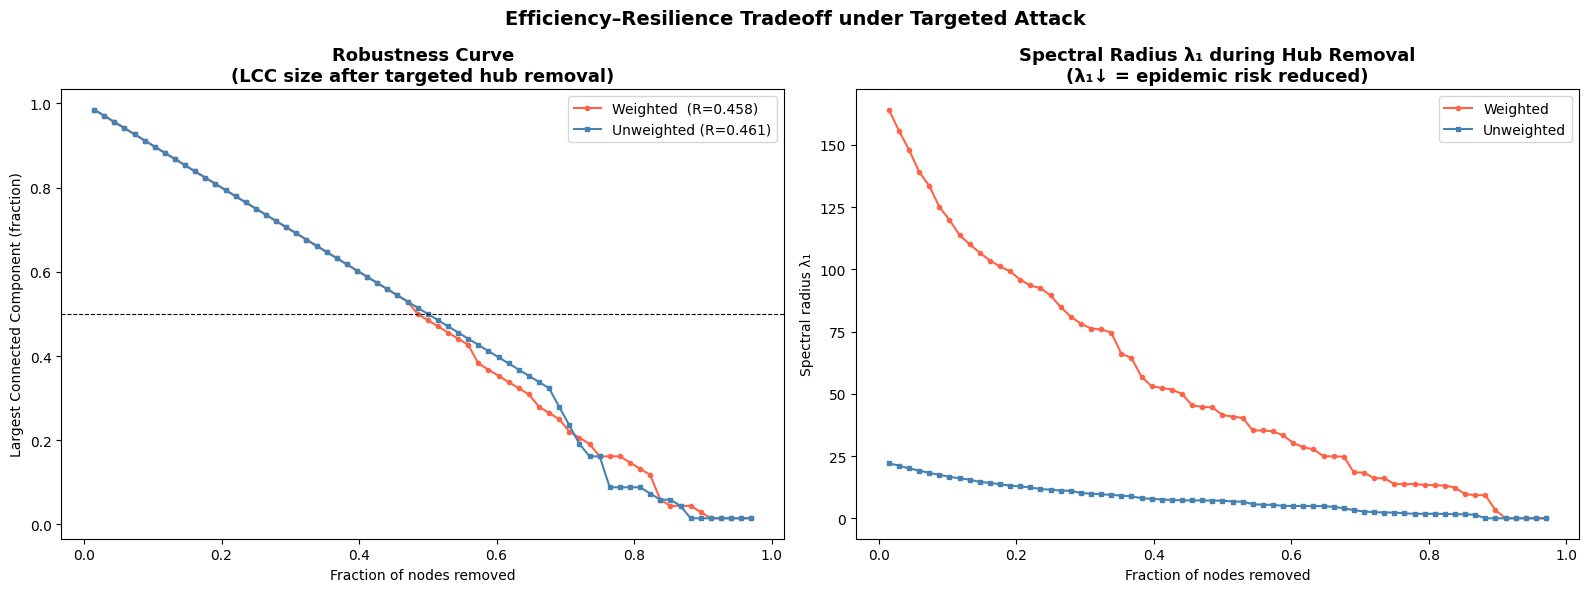

In [11]:
# ── Robustness curve: sequential hub removal ───────────────────────────────────
# Remove nodes one at a time (highest degree first) and track:
#   - Largest connected component size (resilience)
#   - Average path length of remaining graph (efficiency)
#   - Spectral radius drop

order_w  = np.argsort(W_out)[::-1]          # weighted: remove by strength
order_uw = np.argsort(degree_bin)[::-1]     # unweighted: remove by degree

def robustness_curve(A, removal_order):
    lcc_sizes, avg_paths, lambdas = [], [], []
    remaining = list(range(A.shape[0]))
    for step, node in enumerate(removal_order):
        remaining = [r for r in remaining if r != node]
        if len(remaining) < 2:
            break
        sub = A[np.ix_(remaining, remaining)]
        G_sub = nx.from_numpy_array((sub > 0).astype(float))
        lcc = max(nx.connected_components(G_sub), key=len)
        lcc_sizes.append(len(lcc) / A.shape[0])
        ev = np.linalg.eigvalsh(sub).max()
        lambdas.append(ev)
        if nx.is_connected(G_sub) and len(remaining) < 30:
            avg_paths.append(nx.average_shortest_path_length(G_sub))
        else:
            avg_paths.append(np.nan)
    return np.array(lcc_sizes), np.array(avg_paths), np.array(lambdas)

lcc_w,  apl_w,  lam_w  = robustness_curve(sc_ctx, order_w)
lcc_uw, apl_uw, lam_uw = robustness_curve(A_bin, order_uw)

steps_w  = np.arange(1, len(lcc_w)  + 1) / n
steps_uw = np.arange(1, len(lcc_uw) + 1) / n

# Robustness index R = area under LCC curve
R_idx_w  = np.trapz(lcc_w,  steps_w)
R_idx_uw = np.trapz(lcc_uw, steps_uw)
print(f'Robustness index (weighted) : {R_idx_w:.4f}')
print(f'Robustness index (binary)   : {R_idx_uw:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(steps_w,  lcc_w,  'o-', color='tomato',    markersize=3, label=f'Weighted  (R={R_idx_w:.3f})')
axes[0].plot(steps_uw, lcc_uw, 's-', color='steelblue', markersize=3, label=f'Unweighted (R={R_idx_uw:.3f})')
axes[0].set_title('Robustness Curve\n(LCC size after targeted hub removal)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fraction of nodes removed')
axes[0].set_ylabel('Largest Connected Component (fraction)')
axes[0].legend()
axes[0].axhline(0.5, color='k', linewidth=0.8, linestyle='--', label='50% threshold')

axes[1].plot(steps_w,  lam_w,  'o-', color='tomato',    markersize=3, label='Weighted')
axes[1].plot(steps_uw, lam_uw, 's-', color='steelblue', markersize=3, label='Unweighted')
axes[1].set_title('Spectral Radius λ₁ during Hub Removal\n(λ₁↓ = epidemic risk reduced)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fraction of nodes removed')
axes[1].set_ylabel('Spectral radius λ₁')
axes[1].legend()

plt.suptitle('Efficiency–Resilience Tradeoff under Targeted Attack', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hcp_robustness_curve.png', dpi=150, bbox_inches='tight')
plt.show()

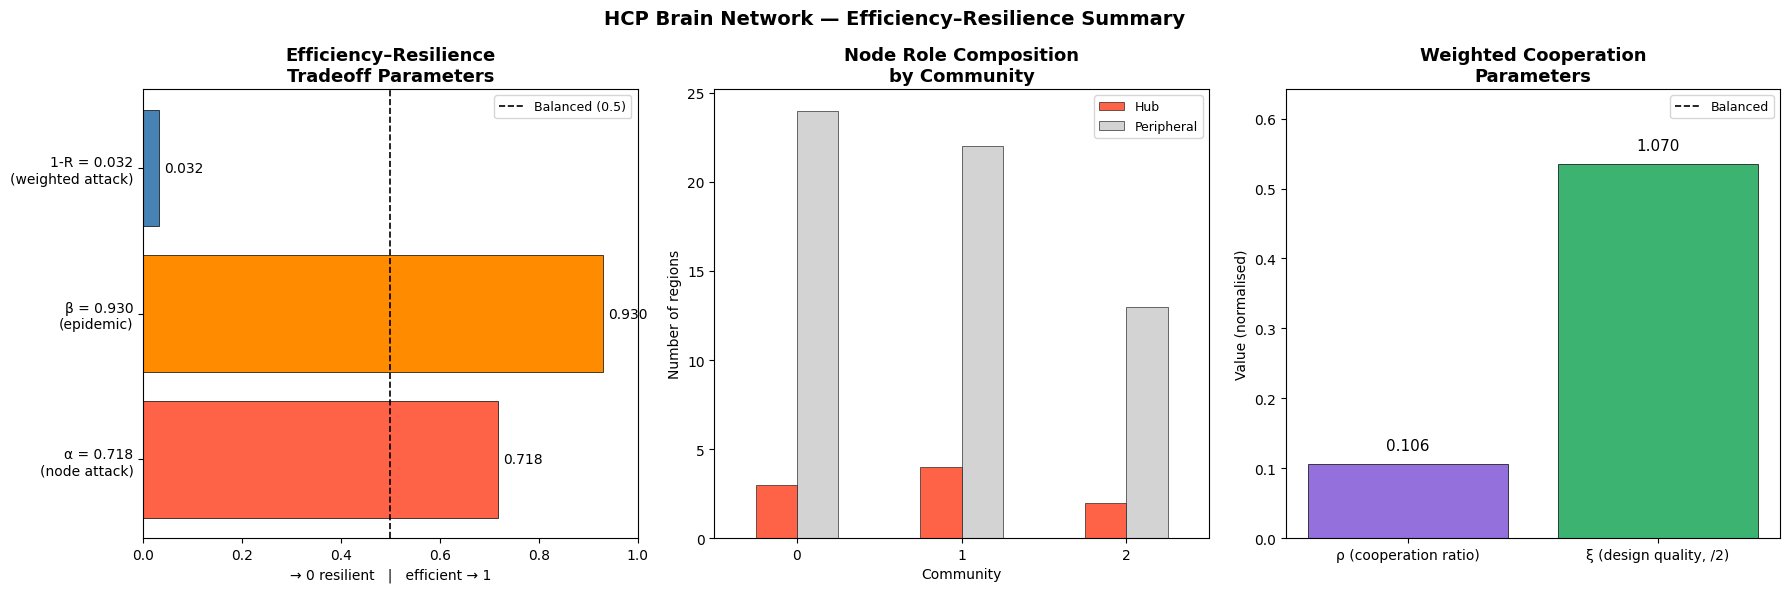


── Final Summary ────────────────────────────────────────────────────────
  Hubs    : ['L_precuneus', 'L_rostralmiddlefrontal', 'L_superiorfrontal', 'L_superiorparietal', 'L_insula']
  Brokers : []
  Bridges : []
  α (node attack tradeoff) = 0.7185  → efficiency-dominant
  β (epidemic tradeoff)    = 0.9302  → efficiency-dominant
  ρ (cooperation ratio)    = 0.1056  → resilience-dominated
  ξ (design quality)       = 1.0702 / 2.0


In [12]:
# ── Summary dashboard ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Panel A: α and β tradeoff dial ───────────────────────────────────────────
params   = [alpha, beta, 1 - R_gamma]
labels_p = [f'α = {alpha:.3f}\n(node attack)', f'β = {beta:.3f}\n(epidemic)', f'1-R = {1-R_gamma:.3f}\n(weighted attack)']
colors_p = ['tomato', 'darkorange', 'steelblue']
bars = axes[0].barh(labels_p, params, color=colors_p, edgecolor='k', linewidth=0.5)
axes[0].axvline(0.5, color='k', linewidth=1.2, linestyle='--', label='Balanced (0.5)')
axes[0].set_xlim(0, 1)
axes[0].set_title('Efficiency–Resilience\nTradeoff Parameters', fontsize=13, fontweight='bold')
axes[0].set_xlabel('→ 0 resilient   |   efficient → 1')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, params):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=10)

# ── Panel B: Role composition by community ───────────────────────────────────
role_comm = role_df.groupby(['Community', 'Role']).size().unstack(fill_value=0)
role_order = ['Hub', 'Broker', 'Bridge', 'Peripheral']
role_comm = role_comm.reindex(columns=[r for r in role_order if r in role_comm.columns])
role_comm.plot(kind='bar', ax=axes[1], color=[role_colors[r] for r in role_comm.columns],
               edgecolor='k', linewidth=0.4)
axes[1].set_title('Node Role Composition\nby Community', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Community')
axes[1].set_ylabel('Number of regions')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(fontsize=9)

# ── Panel C: ρ and ξ cooperation indicators ───────────────────────────────────
coop_names = ['ρ (cooperation ratio)', 'ξ (design quality, /2)']
coop_vals  = [min(rho, 2.0), xi / 2.0]   # normalise ξ to [0,1]
cbars = axes[2].bar(coop_names, coop_vals, color=['mediumpurple', 'mediumseagreen'],
                    edgecolor='k', linewidth=0.5)
axes[2].axhline(1.0, color='k', linewidth=1.2, linestyle='--', label='Balanced')
axes[2].set_title('Weighted Cooperation\nParameters', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Value (normalised)')
axes[2].set_ylim(0, max(coop_vals) * 1.2)
axes[2].legend(fontsize=9)
for bar, val, raw in zip(cbars, coop_vals, [rho, xi]):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{raw:.3f}', ha='center', fontsize=11)

plt.suptitle('HCP Brain Network — Efficiency–Resilience Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hcp_efficiency_resilience_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n── Final Summary ────────────────────────────────────────────────────────')
print(f'  Hubs    : {list(role_df[role_df["Role"]=="Hub"]["Region"][:5])}')
print(f'  Brokers : {list(role_df[role_df["Role"]=="Broker"]["Region"][:5])}')
print(f'  Bridges : {list(role_df[role_df["Role"]=="Bridge"]["Region"][:5])}')
print(f'  α (node attack tradeoff) = {alpha:.4f}  → {"efficiency" if alpha > 0.5 else "resilience"}-dominant')
print(f'  β (epidemic tradeoff)    = {beta:.4f}  → {"efficiency" if beta > 0.5 else "resilience"}-dominant')
print(f'  ρ (cooperation ratio)    = {rho:.4f}  → {"efficiency" if rho > 1 else "resilience"}-dominated')
print(f'  ξ (design quality)       = {xi:.4f} / 2.0')